In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [168]:
df = pd.read_excel('D:\\tugas\\codes\\Machine Learning\\AoL Machine Learning\\Datasets\\Mamikos Jabodetabek Data.xlsx')
df.head()

,room_name,owner_name,region,location,room_size,is_electricity_included,price_before_discount_bs,all_facilities_bs,room_availability_bs,deposit_amount_bs,price,rating,rating_count,transaction_count,tipe_kos,discount_amount,url
0,Kost 0088 Tipe A Babakan Madang Bogor,Yan,Bogor,Babakan Madang,3 x 4 meter,Termasuk listrik (implied),NaN,3 x 4 meter; Termasuk listrik; Kasur; Bantal; ...,NaN,Rp100.000/3 hari,Rp950.000,Not found,Not found,Not found,Kos Campur,Not found,https://mamikos.com/room/kost-kabupaten-bogor-...
1,Kost 121 Cinere Depok,Agustin,Depok,Cinere,4 x 3 meter,Tidak termasuk listrik,NaN,4 x 3 meter; Tidak termasuk listrik; AC; Kasur...,Kamar penuh,NaN,Rp1.100.000,Not found,Not found,Not found,Kos Putra,Not found,https://mamikos.com/room/kost-kota-depok-kost-...
2,Kost 126 Pondok Aren Tangerang Selatan,Hanny,Tangerang Selatan,Kecamatan Pondok Aren,3 x 3 meter,Tidak termasuk listrik,NaN,3 x 3 meter; Tidak termasuk listrik; AC; Kasur...,Tersisa1 kamar,NaN,Rp1.100.000,Not found,Not found,Not found,Kos Putra,Not found,https://mamikos.com/room/kost-kota-tangerang-s...
3,Kost 20088 Babakan Madang Bogor,Yan,Bogor,Babakan Madang,3 x 4 meter,Termasuk listrik (implied),NaN,3 x 4 meter; Termasuk listrik; Kasur; Lemari B...,Tersisa2 kamar,NaN,Rp700.000,Not found,Not found,Not found,Kos Campur,Not found,https://mamikos.com/room/kost-kabupaten-bogor-...
4,Kost 21 Alam Sutera Tipe A Serpong Utara Tange...,Juliandy,Tangerang Selatan,Kecamatan Serpong Utara,2 x 3 meter,Termasuk listrik (implied),NaN,2 x 3 meter; Termasuk listrik; AC; Kasur; Lema...,Tersisa2 kamar,Rp500.000,Rp1.500.000,1.0,Not found,Not found,Kos Putra,Not found,https://mamikos.com/room/kost-kota-tangerang-s...


In [169]:
df.to_csv('D:\\tugas\\codes\\Machine Learning\\AoL Machine Learning\\Datasets\\Data_Indekos_Jabodetabek_Mamikos.csv', index=False)

In [170]:
df = pd.read_csv('D:\\tugas\\codes\\Machine Learning\\AoL Machine Learning\\Datasets\\Data_Indekos_Jabodetabek_Mamikos.csv')
df.head()

,room_name,owner_name,region,location,room_size,is_electricity_included,price_before_discount_bs,all_facilities_bs,room_availability_bs,deposit_amount_bs,price,rating,rating_count,transaction_count,tipe_kos,discount_amount,url
0,Kost 0088 Tipe A Babakan Madang Bogor,Yan,Bogor,Babakan Madang,3 x 4 meter,Termasuk listrik (implied),NaN,3 x 4 meter; Termasuk listrik; Kasur; Bantal; ...,NaN,Rp100.000/3 hari,Rp950.000,Not found,Not found,Not found,Kos Campur,Not found,https://mamikos.com/room/kost-kabupaten-bogor-...
1,Kost 121 Cinere Depok,Agustin,Depok,Cinere,4 x 3 meter,Tidak termasuk listrik,NaN,4 x 3 meter; Tidak termasuk listrik; AC; Kasur...,Kamar penuh,NaN,Rp1.100.000,Not found,Not found,Not found,Kos Putra,Not found,https://mamikos.com/room/kost-kota-depok-kost-...
2,Kost 126 Pondok Aren Tangerang Selatan,Hanny,Tangerang Selatan,Kecamatan Pondok Aren,3 x 3 meter,Tidak termasuk listrik,NaN,3 x 3 meter; Tidak termasuk listrik; AC; Kasur...,Tersisa1 kamar,NaN,Rp1.100.000,Not found,Not found,Not found,Kos Putra,Not found,https://mamikos.com/room/kost-kota-tangerang-s...
3,Kost 20088 Babakan Madang Bogor,Yan,Bogor,Babakan Madang,3 x 4 meter,Termasuk listrik (implied),NaN,3 x 4 meter; Termasuk listrik; Kasur; Lemari B...,Tersisa2 kamar,NaN,Rp700.000,Not found,Not found,Not found,Kos Campur,Not found,https://mamikos.com/room/kost-kabupaten-bogor-...
4,Kost 21 Alam Sutera Tipe A Serpong Utara Tange...,Juliandy,Tangerang Selatan,Kecamatan Serpong Utara,2 x 3 meter,Termasuk listrik (implied),NaN,2 x 3 meter; Termasuk listrik; AC; Kasur; Lema...,Tersisa2 kamar,Rp500.000,Rp1.500.000,1.0,Not found,Not found,Kos Putra,Not found,https://mamikos.com/room/kost-kota-tangerang-s...


## Data Cleaning

In [171]:
df = df[(df['region'] == 'Jakarta Utara') | (df['region'] == 'Jakarta Barat') | (df['region'] == 'Jakarta Pusat') | (df['region'] == 'Jakarta Selatan') | (df['region'] == 'Jakarta Timur')]
df.head()

,room_name,owner_name,region,location,room_size,is_electricity_included,price_before_discount_bs,all_facilities_bs,room_availability_bs,deposit_amount_bs,price,rating,rating_count,transaction_count,tipe_kos,discount_amount,url
7,Kost 2nd Home Tipe Executive Palmerah Jakarta ...,Henry Tirtasaputra Junior,Jakarta Barat,Palmerah,4 x 3 meter,Tidak termasuk listrik,NaN,4 x 3 meter; Tidak termasuk listrik; AC; Kasur...,Tersisa1 kamar,Rp1.000.000,Rp3.100.000,5.0,Not found,Not found,Kos Campur,Diskon 256rb,https://mamikos.com/room/kost-kota-jakarta-bar...
8,Kost 38 Lt3 Tanjung Priok Jakarta Utara,Hadi winata,Jakarta Utara,Tanjung Priok,3 x 3 meter,Termasuk listrik (implied),NaN,3 x 3 meter; Termasuk listrik; Kasur; Meja; Ku...,NaN,Rp10.000/2 hari,Rp700.000,4.1,Not found,Not found,Kos Putra,Not found,https://mamikos.com/room/kost-kota-jakarta-uta...
9,Kost 3tranches Home SCBD Tipe A Kebayoran Baru...,Threetranches Manajemen,Jakarta Selatan,Kebayoran Baru,3 x 5 meter,Tidak termasuk listrik,NaN,3 x 5 meter; Tidak termasuk listrik; AC; Kasur...,NaN,Rp1.000.000,Rp3.500.000,4.0,(5),22 transaksi berhasil di kos ini,Kos Campur,Not found,https://mamikos.com/room/kost-kota-jakarta-sel...
10,Kost 3tranches Home Senopati Kebayoran Baru Ja...,Threetranches Manajemen,Jakarta Selatan,Kebayoran Baru,4 x 4 meter,Tidak termasuk listrik,NaN,4 x 4 meter; Tidak termasuk listrik; AC; Kasur...,NaN,Rp1.000.000,Rp3.800.000,4.6,Not found,13 transaksi berhasil di kos ini,Kos Campur,Diskon 304rb,https://mamikos.com/room/kost-kota-jakarta-sel...
11,Kost 3tranches Home Tipe D Cilandak Jakarta Se...,Threetranches Manajemen,Jakarta Selatan,Cilandak,4.6 x 6 meter,Tidak termasuk listrik,NaN,4.6 x 6 meter; Tidak termasuk listrik; AC; Kas...,NaN,NaN,Rp4.000.000,3.6,(1),12 transaksi berhasil di kos ini,Kos Campur,Diskon 193rb,https://mamikos.com/room/kost-kota-jakarta-sel...


In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1233 entries, 7 to 2481
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   room_name                 1233 non-null   object
 1   owner_name                1233 non-null   object
 2   region                    1233 non-null   object
 3   location                  1233 non-null   object
 4   room_size                 1212 non-null   object
 5   is_electricity_included   1213 non-null   object
 6   price_before_discount_bs  440 non-null    object
 7   all_facilities_bs         1214 non-null   object
 8   room_availability_bs      1024 non-null   object
 9   deposit_amount_bs         995 non-null    object
 10  price                     1233 non-null   object
 11  rating                    1233 non-null   object
 12  rating_count              1233 non-null   object
 13  transaction_count         1233 non-null   object
 14  tipe_kos                  123

In [173]:
for col in df.columns:
    print(f"Unique values in '{col}': {df[col].unique()}")

Unique values in 'room_name': ['Kost 2nd Home Tipe Executive Palmerah Jakarta Barat'
 'Kost 38 Lt3 Tanjung Priok Jakarta Utara'
 'Kost 3tranches Home SCBD Tipe A Kebayoran Baru Jakarta Selatan' ...
 'Kost Yudi Residence Tipe C Tanjung Priok Jakarta Utara'
 'Kost Yume Home Executive Kali Deres Jakarta Barat'
 'Rumah Kontrakan Komplek Sunter Jaya Baru Tanjung Priok Jakarta Utara']
Unique values in 'owner_name': ['Henry Tirtasaputra Junior' 'Hadi winata' 'Threetranches Manajemen'
 'Naimi Gandaria Simanjuntak' 'ibu arif' 'Alya' 'IIN KOST PUTRI'
 'Pemilik Kos' 'ibu akim' 'Oki Inderawan' 'Fifik Asfiati R'
 'Almic Guesthouse Jakarta' 'Admin Almic kost' 'Amriyani'
 'Paulina Pangabean' 'Ratna Kusuma Dewi' 'Aisyatul umro'
 'Kos dikelola oleh Dida' 'Kos dikelola oleh Bella'
 'Kos dikelola oleh Maya' 'Eva' 'Andrias Suganda' 'Angela Catharina'
 'Dini Hilyah' 'meila sutanti' 'Ivana' 'William Iskandar' 'nanda soraya'
 'yuli' 'Debby Febrian' 'Yuferdi' 'Irwin' 'Emiliana Riyadi Eti' 'Melita'
 'Koster Co

### cleaning price

In [174]:
df['price'] = df['price'].str.replace('Rp', '').str.replace('.', '').astype(float)

In [175]:
df['discount_amount'] = df['discount_amount'].replace('Not found', 0)
df['discount_amount'] = df['discount_amount'].astype(str).str.extract(r'(\d+)').astype(float).fillna(0) * 1000

In [176]:
df['price_before_discount_bs'] = df['price'] + df['discount_amount']

### clean rating

In [177]:
df['rating'] = df['rating'].replace('Not found', 0).astype(float).fillna(0)
df['rating_count'] = df['rating_count'].replace('Not found', 0)
df['rating_count'] = df['rating_count'].astype(str).str.replace(r'[()]', '', regex=True).astype(float).fillna(0)
df.loc[df['rating_count'] == 0, 'rating'] = 0

### clean transaction count

In [178]:
df['transaction_count'] = df['transaction_count'].replace('Not found', 0)
df['transaction_count'] = df['transaction_count'].astype(str).str.extract(r'(\d+)').astype(float).fillna(0)

### clean luas kamar

In [179]:
df[['length', 'width']] = df['room_size'].astype(str).str.extract(r'([\d\.]+)\s*x\s*([\d\.]+)').astype(float)
df['room_area'] = df['length'] * df['width']

In [180]:
df['room_area'] = df['room_area'].fillna(df['room_area'].mode()[0], inplace=False)

### clean ketersediaan kamar

In [181]:
df['room_availability_bs']=df['room_availability_bs'].map({'Tersisa1 kamar': 1,
    'Tersisa2 kamar': 2,
    'Kamar penuh,lihat kos lainnya': 0,
    'Kamar penuh,lihat tipe kamar lainnya': 0,
    'Tersisa3 kamar': 3
}).fillna(0)

### cek harga rata-rata sesuai tipe kos(campur,putra, putri)

In [182]:
df_grouped = df.groupby('tipe_kos')['price'].agg(
    Rata_Rata='mean',
    Median='median',
    Jumlah_Kos='count'
).reset_index()

In [183]:
df_grouped['Rata_Rata'] = df_grouped['Rata_Rata'].round(2)
print("--- Tabel Analisis Harga Berdasarkan Tipe Kos (Jakarta) ---")
print(df_grouped)

--- Tabel Analisis Harga Berdasarkan Tipe Kos (Jakarta) ---
     tipe_kos   Rata_Rata     Median  Jumlah_Kos
0  Kos Campur  2029651.65  1865000.0         785
1   Kos Putra  1436244.52  1282500.0          93
2   Kos Putri  1800883.94  1727000.0         355


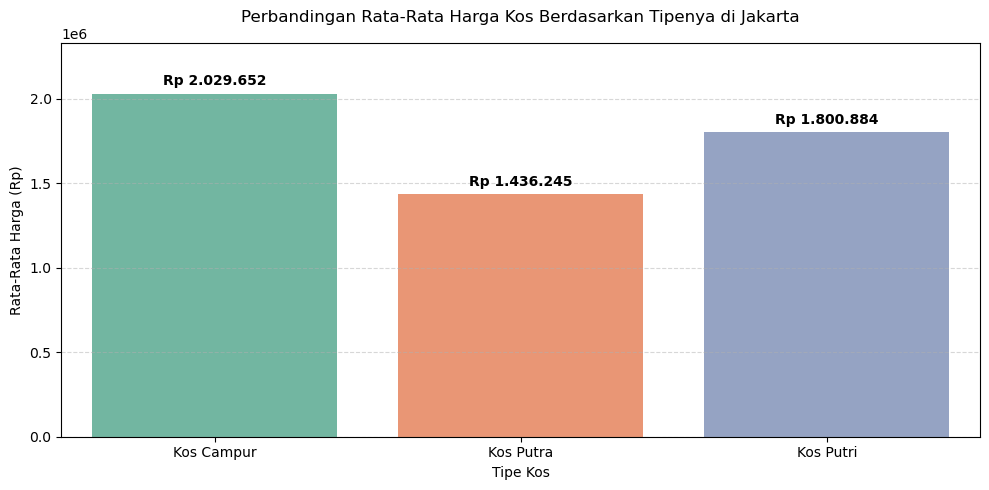

In [184]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_grouped, 
    x='tipe_kos', 
    y='Rata_Rata', 
    palette='Set2', 
    hue='tipe_kos', 
    legend=False
)

for index, row in df_grouped.iterrows():
    plt.text(
        x=index, 
        y=row['Rata_Rata'] + 30000, 
        s=f"Rp {row['Rata_Rata']:,.0f}".replace(",", "."), 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        weight='bold'
    )

plt.title('Perbandingan Rata-Rata Harga Kos Berdasarkan Tipenya di Jakarta', fontsize=12, pad=15)
plt.xlabel('Tipe Kos', fontsize=10)
plt.ylabel('Rata-Rata Harga (Rp)', fontsize=10)
plt.ylim(0, max(df_grouped['Rata_Rata']) + 300000) # Memberi ruang untuk label teks
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

harga yang paling mahal kos campur -> kos perempuan -> kos laki2

### cek harga rata-rata dari region

In [185]:
df_grouped = df.groupby('region')['price'].agg(
    Rata_Rata='mean',
    Median='median',
    Jumlah_Kos='count'
).reset_index()

In [186]:
df_grouped['Rata_Rata'] = df_grouped['Rata_Rata'].round(2)
print("--- Tabel Analisis Harga Berdasarkan Tipe Kos (Jakarta) ---")
print(df_grouped)

--- Tabel Analisis Harga Berdasarkan Tipe Kos (Jakarta) ---
            region   Rata_Rata     Median  Jumlah_Kos
0    Jakarta Barat  2041154.97  1957000.0         231
1    Jakarta Pusat  2054337.77  1850000.0         229
2  Jakarta Selatan  2337112.03  2210000.0         241
3    Jakarta Timur  1549845.44  1497250.0         298
4    Jakarta Utara  1705611.10  1612500.0         234


jaksel -> jakpus -> jakbar -> jakut -> jaktim

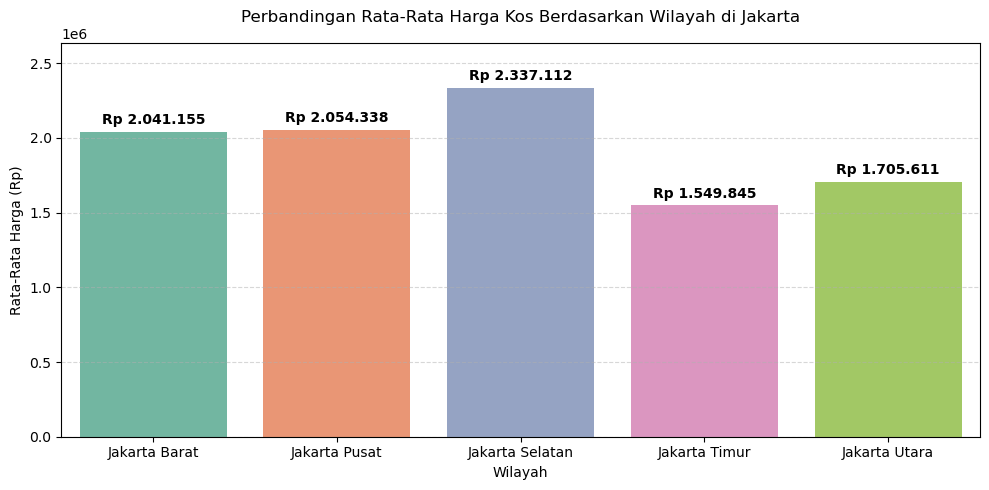

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_grouped, 
    x='region', 
    y='Rata_Rata', 
    palette='Set2', 
    hue='region', 
    legend=False
)

for index, row in df_grouped.iterrows():
    plt.text(
        x=index, 
        y=row['Rata_Rata'] + 30000, 
        s=f"Rp {row['Rata_Rata']:,.0f}".replace(",", "."), 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        weight='bold'
    )

plt.title('Perbandingan Rata-Rata Harga Kos Berdasarkan Wilayah di Jakarta', fontsize=12, pad=15)
plt.xlabel('Wilayah', fontsize=10)
plt.ylabel('Rata-Rata Harga (Rp)', fontsize=10)
plt.ylim(0, max(df_grouped['Rata_Rata']) + 300000) # Memberi ruang untuk label teks
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### facilities

In [ ]:
df['all_facilities_bs'] = df['all_facilities_bs'].str.strip().fillna('')

teks_listrik_bersih = df['is_electricity_included'].fillna('').astype(str).str.strip().str.lower()
df['is_electricity'] = teks_listrik_bersih.apply(
    lambda x: 1 if 'termasuk listrik' in x and 'tidak' not in x else 0
)

def check_fac(text, keywords):
    return 1 if any(word in text for word in keywords) else 0

print("Mengelompokkan fasilitas serupa...")

df['is_kamar_mandi_dalam'] = df['all_facilities_bs'].apply(lambda x: 1 if 'K. Mandi Dalam' in x else 0)
df['is_kloset_duduk'] = df['all_facilities_bs'].apply(lambda x: 1 if 'Kloset Duduk' in x else 0)

df['fac_keamanan'] = df['all_facilities_bs'].apply(lambda x: check_fac(x, ['CCTV', 'Penjaga Kos', 'Pengurus Kos']))

df['fac_sirkulasi_udara'] = df['all_facilities_bs'].apply(lambda x: check_fac(x, ['Jendela', 'Ventilasi']))

df['fac_parkir_motor'] = df['all_facilities_bs'].apply(lambda x: check_fac(x, ['Parkir Motor', 'Parkir Sepeda', 'Parkir Motor & Sepeda']))
df['fac_parkir_mobil'] = df['all_facilities_bs'].apply(lambda x: check_fac(x, ['Parkir Mobil']))

df['fac_ruang_bersama'] = df['all_facilities_bs'].apply(lambda x: check_fac(x, ['R. Tamu', 'R. Makan', 'R. Santai', 'Rooftop', 'Balcon', 'Taman']))

df['fac_layanan_kebersihan'] = df['all_facilities_bs'].apply(lambda x: check_fac(x, ['Laundry', 'Mesin Cuci', 'Cleaning service', 'R. Cuci']))
df['fac_area_jemur'] = df['all_facilities_bs'].apply(lambda x: check_fac(x, ['R. Jemur', 'Jemuran']))

df['is_full_furnished'] = df['all_facilities_bs'].apply(
    lambda x: 1 if all(word in x for word in ['Kasur', 'Lemari Baju', 'Meja']) else 0
)

keywords_to_skip = [
    'meter', 'listrik', 'K. Mandi', 'Parkir', 'R. ', 'Jemur', 'Laundry', 'Cleaning', 
    'Kasur', 'Lemari', 'Meja', 'CCTV', 'Penjaga', 'Pengurus', 'Jendela', 'Ventilasi', 'Kloset', 'Taman', 'Rooftop', 'Balcon', 'R. Tamu', 'R. Makan', 'R. Santai',
]

all_facilities_list = []
for x in df['all_facilities_bs'].str.split(';'):
    for item in x:
        item = item.strip()
        if item and not any(skip in item for skip in keywords_to_skip):
            all_facilities_list.append(item)

fac_counts = Counter(all_facilities_list)
pop_facs = [f for f, c in fac_counts.items() if c > 50]

list_kolom_fac_tambahan = []
for fac in pop_facs:
    nama_kolom = f"fac_{fac.lower().replace(' ', '_').replace('.', '').replace('&', 'and')}"
    list_kolom_fac_tambahan.append(nama_kolom)
    df[nama_kolom] = df['all_facilities_bs'].apply(
        lambda x: 1 if fac in [i.strip() for i in x.split(';')] else 0
    )

fitur_grouping = [
    'is_kloset_duduk', 'fac_keamanan', 'fac_sirkulasi_udara', 
    'fac_parkir_motor', 'fac_parkir_mobil', 'fac_ruang_bersama', 
    'fac_layanan_kebersihan', 'fac_area_jemur', 'is_full_furnished'
]

features_to_use = [
    'room_area', 'is_electricity', 'is_kamar_mandi_dalam', 'is_discount', 
    'region', 'tipe_kos'
] + fitur_grouping + list_kolom_fac_tambahan

print(f"\nTotal Fitur yang digunakan: {len(features_to_use)}")
print(f"Daftar Fitur: {features_to_use}")

Mengelompokkan fasilitas serupa...

Total Fitur yang digunakan: 32
Daftar Fitur: ['room_area', 'is_electricity', 'is_kamar_mandi_dalam', 'is_discount', 'region', 'tipe_kos', 'is_kloset_duduk', 'fac_keamanan', 'fac_sirkulasi_udara', 'fac_parkir_motor', 'fac_parkir_mobil', 'fac_ruang_bersama', 'fac_layanan_kebersihan', 'fac_area_jemur', 'is_full_furnished', 'fac_ac', 'fac_tv', 'fac_bantal', 'fac_cermin', 'fac_shower', 'fac_air_panas', 'fac_wifi', 'fac_kulkas', 'fac_dapur', 'fac_dispenser', 'fac_kipas_angin', 'fac_kursi', 'fac_guling', 'fac_wastafel', 'fac_ember_mandi', 'fac_mesin_cuci', 'fac_bak_mandi']


In [189]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1233 entries, 7 to 2481
Data columns (total 48 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   room_name                 1233 non-null   object 
 1   owner_name                1233 non-null   object 
 2   region                    1233 non-null   object 
 3   location                  1233 non-null   object 
 4   room_size                 1212 non-null   object 
 5   is_electricity_included   1213 non-null   object 
 6   price_before_discount_bs  1233 non-null   float64
 7   all_facilities_bs         1233 non-null   object 
 8   room_availability_bs      1233 non-null   float64
 9   deposit_amount_bs         995 non-null    object 
 10  price                     1233 non-null   float64
 11  rating                    1233 non-null   float64
 12  rating_count              1233 non-null   float64
 13  transaction_count         1233 non-null   float64
 14  tipe_kos     

## drop kolom yang tidak dipakai

In [191]:
df['is_discount'] = df.apply(
    lambda row: 1 if row['discount_amount'] > 0 else 0, 
    axis=1
)

In [192]:
df = df.drop(columns=['length', 'width', 'room_size', 'is_electricity_included', 'url', 'owner_name','deposit_amount_bs', 'all_facilities_bs','room_name', 'discount_amount', 'price_before_discount_bs'])

In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1233 entries, 7 to 2481
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   region                  1233 non-null   object 
 1   location                1233 non-null   object 
 2   room_availability_bs    1233 non-null   float64
 3   price                   1233 non-null   float64
 4   rating                  1233 non-null   float64
 5   rating_count            1233 non-null   float64
 6   transaction_count       1233 non-null   float64
 7   tipe_kos                1233 non-null   object 
 8   room_area               1233 non-null   float64
 9   is_electricity          1233 non-null   int64  
 10  is_kamar_mandi_dalam    1233 non-null   int64  
 11  is_kloset_duduk         1233 non-null   int64  
 12  fac_keamanan            1233 non-null   int64  
 13  fac_sirkulasi_udara     1233 non-null   int64  
 14  fac_parkir_motor        1233 non-null   int64

In [194]:
df.head()

,region,location,room_availability_bs,price,rating,rating_count,transaction_count,tipe_kos,room_area,is_electricity,...,fac_dapur,fac_dispenser,fac_kipas_angin,fac_kursi,fac_guling,fac_wastafel,fac_ember_mandi,fac_mesin_cuci,fac_bak_mandi,is_discount
7,Jakarta Barat,Palmerah,1.0,3100000.0,0.0,0.0,0.0,Kos Campur,12.0,0,...,1,1,0,0,0,0,0,0,0,1
8,Jakarta Utara,Tanjung Priok,0.0,700000.0,0.0,0.0,0.0,Kos Putra,9.0,1,...,1,0,1,0,0,0,0,0,0,0
9,Jakarta Selatan,Kebayoran Baru,0.0,3500000.0,4.0,5.0,22.0,Kos Campur,15.0,0,...,1,1,0,1,1,1,0,0,0,0
10,Jakarta Selatan,Kebayoran Baru,0.0,3800000.0,0.0,0.0,13.0,Kos Campur,16.0,0,...,1,1,0,0,1,1,0,0,0,1
11,Jakarta Selatan,Cilandak,0.0,4000000.0,3.6,1.0,12.0,Kos Campur,27.6,0,...,1,1,0,0,1,1,0,0,0,1


## Model

In [195]:
X = df.drop(columns=['price', 'location'])
y = df['price']

X = pd.get_dummies(X, columns=['region', 'tipe_kos'], drop_first=True)
X = X.astype(float) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("\n==================================================")
print("===    HASIL EVALUASI MODEL PIPELINE AKHIR     ===")
print("==================================================")
print(f"R2 Score (Pada Skala Logarithm) : {r2:.4f}")
print(f"Mean Absolute Error (Rupiah)    : Rp {mae:,.0f}".replace(",", "."))
print("==================================================")



===    HASIL EVALUASI MODEL PIPELINE AKHIR     ===
R2 Score (Pada Skala Logarithm) : 0.7558
Mean Absolute Error (Rupiah)    : Rp 243.227


In [ ]:
X = df.drop(columns=['price', 'location'])
y = np.log1p(df['price']) 

X = pd.get_dummies(X, columns=['region', 'tipe_kos'], drop_first=True)
X = X.astype(float) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_log = rf_model.predict(X_test)

r2 = r2_score(y_test, y_pred_log)

y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)
mae = mean_absolute_error(y_test_original, y_pred_original)

print("\n==================================================")
print("===    HASIL EVALUASI MODEL PIPELINE AKHIR     ===")
print("==================================================")
print(f"R2 Score (Pada Skala Logarithm) : {r2:.4f}")
print(f"Mean Absolute Error (Rupiah)    : Rp {mae:,.0f}".replace(",", "."))
print("==================================================")


===    HASIL EVALUASI MODEL PIPELINE AKHIR     ===
R2 Score (Pada Skala Logarithm) : 0.8080
Mean Absolute Error (Rupiah)    : Rp 244.172


In [198]:
df.to_csv('D:\\tugas\\codes\\Machine Learning\\AoL Machine Learning\\prediksi_harga_kos\\data\\Data_Indekos_Jabodetabek_Mamikos_Processed.csv', index=False)

## Visualisasi Hasil Akurasi

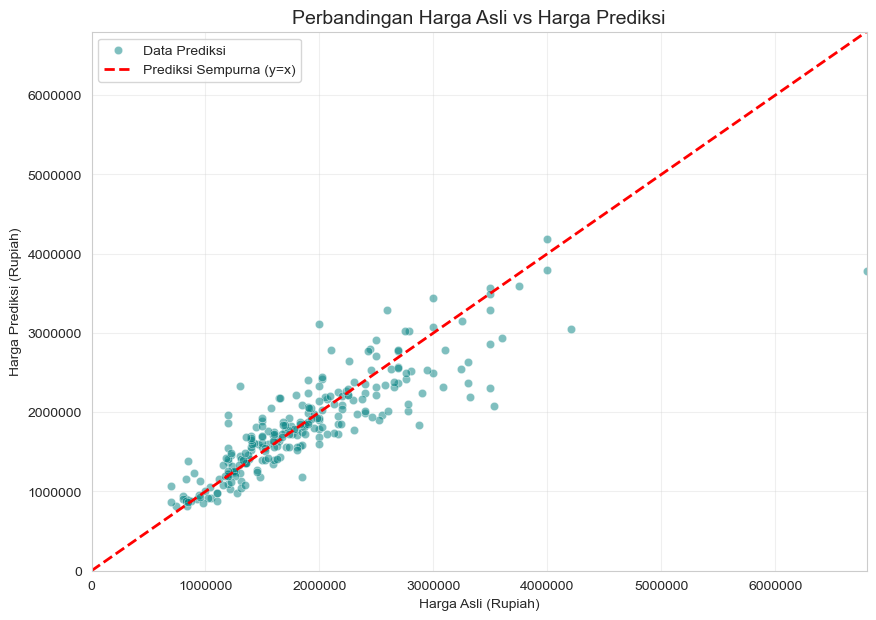

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(x=y_test_original, y=y_pred_original, alpha=0.5, color='teal', label='Data Prediksi')

max_val = int(max(y_test_original.max(), y_pred_original.max()))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', lw=2, label='Prediksi Sempurna (y=x)')

plt.title('Perbandingan Harga Asli vs Harga Prediksi', fontsize=14)
plt.xlabel('Harga Asli (Rupiah)')
plt.ylabel('Harga Prediksi (Rupiah)')

plt.ticklabel_format(style='plain', axis='both')
plt.xlim(0, max_val)
plt.ylim(0, max_val)

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()